In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import zipfile
import os
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
RAW_ZIP  = Path("../data/raw/PlantVillage.zip")
TEMP_DIR = Path("../data/raw/PlantVillage_temp")   # temporary extraction – NOT processed/
PROCESSED = Path("../data/processed")

# ── Extract to temp only if not already done ──────────────────────────────────
if TEMP_DIR.exists() and any(TEMP_DIR.iterdir()):
    print(f"Already extracted to temp dir: {TEMP_DIR}")
else:
    TEMP_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {RAW_ZIP.name} -> {TEMP_DIR} ...")
    with zipfile.ZipFile(RAW_ZIP, "r") as zf:
        zf.extractall(TEMP_DIR)
    print("Extraction complete!")

# ── Ensure processed/ exists ──────────────────────────────────────────────────
PROCESSED.mkdir(parents=True, exist_ok=True)
print(f"\nTemp dir  : {TEMP_DIR}")
print(f"Processed : {PROCESSED}  <- only train/ val/ test/ will live here")


Extracting PlantVillage.zip -> ..\data\raw\PlantVillage_temp ...
Extraction complete!

Temp dir  : ..\data\raw\PlantVillage_temp
Processed : ..\data\processed  <- only train/ val/ test/ will live here


In [3]:
import os
import shutil
import random
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
TEMP_DIR                       = Path("../data/raw/PlantVillage_temp")
target_train_dir               = Path("../data/processed/train")
num_images_per_class_for_train = 600

# ── Find class folders inside temp extraction ─────────────────────────────────
source_data_root = None
for root, dirs, files in os.walk(TEMP_DIR):
    if any("Tomato" in d for d in dirs) and len(dirs) > 1:
        source_data_root = Path(root)
        break

if source_data_root is None:
    print(f"Error: Could not find class folders under {TEMP_DIR}.")
    print("Check the zip structure — expected PlantVillage_Dataset/color/CLASS_NAME.")
else:
    print(f"Found source data root: {source_data_root}")

    # ── Create/clean train dir ────────────────────────────────────────────────
    if target_train_dir.exists():
        print(f"Removing existing train dir: {target_train_dir}")
        shutil.rmtree(target_train_dir)
    target_train_dir.mkdir(parents=True, exist_ok=True)
    print(f"Created: {target_train_dir}")

    # ── Copy selected images per class ────────────────────────────────────────
    all_classes = sorted([d.name for d in source_data_root.iterdir() if d.is_dir()])
    print(f"Detected classes ({len(all_classes)}): {all_classes}")

    for class_name in all_classes:
        source_class_dir = source_data_root / class_name
        dest_class_dir   = target_train_dir / class_name
        dest_class_dir.mkdir(parents=True, exist_ok=True)

        images = []
        for ext in ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]:
            images.extend(list(source_class_dir.glob(ext)))

        if not images:
            print(f"  Warning: no images in {source_class_dir}. Skipping.")
            continue

        random.seed(42)
        random.shuffle(images)
        selected = images[:num_images_per_class_for_train]

        for img in selected:
            shutil.copy(img, dest_class_dir / img.name)
        print(f"  {class_name}: {len(selected)} images copied")

    print("\nTraining dataset ready at:", target_train_dir)


Found source data root: ..\data\raw\PlantVillage_temp\PlantVillage
Created: ..\data\processed\train
Detected classes (6): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato__Target_Spot', 'Tomato_healthy']
  Tomato_Bacterial_spot: 600 images copied
  Tomato_Early_blight: 600 images copied
  Tomato_Late_blight: 600 images copied
  Tomato_Leaf_Mold: 600 images copied
  Tomato__Target_Spot: 600 images copied
  Tomato_healthy: 600 images copied

Training dataset ready at: ..\data\processed\train


In [4]:
IMAGE_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
SEED = 42

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="reflect"
)

train_generator = train_gen.flow_from_directory(
    "../data/processed/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True,
    seed=SEED
)

Found 3232 images belonging to 6 classes.


In [5]:
import os
import shutil
import random
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
TEMP_DIR                     = Path("../data/raw/PlantVillage_temp")
target_val_dir               = Path("../data/processed/val")
train_root_dir               = Path("../data/processed/train")
num_images_per_class_for_val = 150

print("Starting validation dataset preparation...")

# ── Find class folders ────────────────────────────────────────────────────────
source_data_root = None
for root, dirs, files in os.walk(TEMP_DIR):
    if any("Tomato" in d for d in dirs) and len(dirs) > 1:
        source_data_root = Path(root)
        break

all_classes = sorted([d.name for d in source_data_root.iterdir() if d.is_dir()])

# ── Create/clean val dir ──────────────────────────────────────────────────────
if target_val_dir.exists():
    print(f"Removing existing val dir: {target_val_dir}")
    shutil.rmtree(target_val_dir)
target_val_dir.mkdir(parents=True, exist_ok=True)
print(f"Created: {target_val_dir}")

# ── Collect already-used training images ──────────────────────────────────────
images_in_train = set()
for class_name in all_classes:
    class_train_path = train_root_dir / class_name
    if class_train_path.is_dir():
        for img_path in class_train_path.iterdir():
            images_in_train.add(img_path.resolve())
print(f"Training images to exclude: {len(images_in_train)}")

# ── Populate val dir ──────────────────────────────────────────────────────────
random.seed(SEED)
for class_name in all_classes:
    source_class_dir = source_data_root / class_name
    dest_class_dir   = target_val_dir / class_name
    dest_class_dir.mkdir(parents=True, exist_ok=True)

    all_imgs = []
    for ext in ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]:
        all_imgs.extend(list(source_class_dir.glob(ext)))

    available = [p for p in all_imgs if p.resolve() not in images_in_train]
    random.shuffle(available)
    selected = available[:num_images_per_class_for_val]

    if not selected:
        print(f"  Warning: no unique images for val in '{class_name}'. Skipping.")
        continue

    for img in selected:
        shutil.copy(img, dest_class_dir / img.name)
    print(f"  {class_name}: {len(selected)} images copied")

print("\nValidation dataset ready at:", target_val_dir)

# ── ImageDataGenerator for validation ─────────────────────────────────────────
valid_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
valid_generator = valid_gen.flow_from_directory(
    str(target_val_dir),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Starting validation dataset preparation...
Created: ..\data\processed\val
Training images to exclude: 3232
  Tomato_Bacterial_spot: 150 images copied
  Tomato_Early_blight: 150 images copied
  Tomato_Late_blight: 150 images copied
  Tomato_Leaf_Mold: 150 images copied
  Tomato__Target_Spot: 150 images copied
  Tomato_healthy: 150 images copied

Validation dataset ready at: ..\data\processed\val
Found 882 images belonging to 6 classes.


In [6]:
import os
import shutil
import random
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
TEMP_DIR                      = Path("../data/raw/PlantVillage_temp")
target_test_dir               = Path("../data/processed/test")
train_root_dir                = Path("../data/processed/train")
val_root_dir                  = Path("../data/processed/val")
num_images_per_class_for_test = 150

print("Starting test dataset preparation...")

# ── Find class folders ────────────────────────────────────────────────────────
source_data_root = None
for root, dirs, files in os.walk(TEMP_DIR):
    if any("Tomato" in d for d in dirs) and len(dirs) > 1:
        source_data_root = Path(root)
        break

all_classes = sorted([d.name for d in source_data_root.iterdir() if d.is_dir()])

# ── Create/clean test dir ─────────────────────────────────────────────────────
if target_test_dir.exists():
    print(f"Removing existing test dir: {target_test_dir}")
    shutil.rmtree(target_test_dir)
target_test_dir.mkdir(parents=True, exist_ok=True)
print(f"Created: {target_test_dir}")

# ── Collect already-used train + val images ───────────────────────────────────
used_images = set()
for class_name in all_classes:
    for split_dir in [train_root_dir, val_root_dir]:
        class_path = split_dir / class_name
        if class_path.is_dir():
            for img_path in class_path.iterdir():
                used_images.add(img_path.resolve())
print(f"Train + val images to exclude: {len(used_images)}")

# ── Populate test dir ─────────────────────────────────────────────────────────
random.seed(SEED)
for class_name in all_classes:
    source_class_dir = source_data_root / class_name
    dest_class_dir   = target_test_dir / class_name
    dest_class_dir.mkdir(parents=True, exist_ok=True)

    all_imgs = []
    for ext in ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]:
        all_imgs.extend(list(source_class_dir.glob(ext)))

    available = [p for p in all_imgs if p.resolve() not in used_images]
    random.shuffle(available)
    selected = available[:num_images_per_class_for_test]

    if not selected:
        print(f"  Warning: no unique images for test in '{class_name}'. Skipping.")
        continue

    for img in selected:
        shutil.copy(img, dest_class_dir / img.name)
    print(f"  {class_name}: {len(selected)} images copied")

print("\nTest dataset ready at:", target_test_dir)

# ── Clean up temp extraction (no longer needed) ───────────────────────────────
print(f"\nCleaning up temp extraction: {TEMP_DIR} ...")
shutil.rmtree(TEMP_DIR)
print("Temp folder removed. processed/ now contains ONLY: train/ val/ test/")

# ── ImageDataGenerator for test ───────────────────────────────────────────────
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_gen.flow_from_directory(
    str(target_test_dir),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Starting test dataset preparation...
Created: ..\data\processed\test
Train + val images to exclude: 4114
  Tomato_Bacterial_spot: 150 images copied
  Tomato_Early_blight: 150 images copied
  Tomato_Late_blight: 150 images copied
  Tomato_Leaf_Mold: 150 images copied
  Tomato__Target_Spot: 150 images copied
  Tomato_healthy: 150 images copied

Test dataset ready at: ..\data\processed\test

Cleaning up temp extraction: ..\data\raw\PlantVillage_temp ...
Temp folder removed. processed/ now contains ONLY: train/ val/ test/
Found 882 images belonging to 6 classes.


In [7]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 6

base_model = EfficientNetB0(
    include_top=False,
    input_shape=input_shape,
    weights="imagenet",
    pooling="avg"
)
base_model.trainable = False  # freeze backbone for a stable warmup

model = models.Sequential([
    layers.Input(shape=input_shape),
    base_model,
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 1280)             4049571   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 6)                 1542      
                                                                 
Total params: 4,379,049
Trainable params: 329,478
Non-trainable params: 4,049,571
_________________________________________________________________


In [9]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [10]:
train_steps = len(train_generator)
valid_steps = len(valid_generator)
train_steps, valid_steps

(101, 28)

In [11]:
import json
import numpy as np

# ── Permanently patch JSONEncoder to handle EagerTensors & numpy types ────────
# TF 2.11 ModelCheckpoint serializes tensors internally; patching the encoder
# is the only guaranteed fix regardless of callback order.
_orig_default = json.JSONEncoder.default

def _tensor_safe_default(self, obj):
    if hasattr(obj, 'numpy'):          # EagerTensor
        val = obj.numpy()
        return float(val) if val.ndim == 0 else [float(x) for x in val.flatten()]
    if isinstance(obj, np.ndarray):
        return float(obj) if obj.ndim == 0 else [float(x) for x in obj.flatten()]
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    return _orig_default(self, obj)

json.JSONEncoder.default = _tensor_safe_default
print('JSON encoder patched - EagerTensors are now serializable.')

# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_effnetb0.keras",
    monitor="val_loss",
    save_best_only=True
)


In [12]:
import os
from pathlib import Path

def count_images_in_dataset(base_dir_name="../data/processed"):
    base_dir = Path(base_dir_name)
    if not base_dir.exists():
        print(f"Error: Base directory '{base_dir}' not found.")
        return

    print(f"\n--- Image counts in '{base_dir}' subdirectories ---")

    sub_dirs = ["train", "val", "test"]
    image_extensions = ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]

    total_dataset_images = 0

    for sub_dir_name in sub_dirs:
        current_dir = base_dir / sub_dir_name
        if not current_dir.is_dir():
            print(f"Directory '{current_dir}' not found. Skipping.")
            continue

        print(f"\n-- {sub_dir_name.capitalize()} Set --")
        total_sub_dir_images = 0

        class_dirs = sorted([d for d in current_dir.iterdir() if d.is_dir()])

        if not class_dirs:
            print(f"No class directories found in '{current_dir}'.")
            continue

        for class_dir in class_dirs:
            class_name = class_dir.name
            image_count = 0
            for ext in image_extensions:
                image_count += len(list(class_dir.glob(ext)))
            print(f"  Class '{class_name}': {image_count} images")
            total_sub_dir_images += image_count
        print(f"Total images in {sub_dir_name.capitalize()} Set: {total_sub_dir_images}")
        total_dataset_images += total_sub_dir_images

    print(f"\nTotal images across all sets in '{base_dir}': {total_dataset_images}")

# Call the function to count images
count_images_in_dataset()



--- Image counts in '..\data\processed' subdirectories ---

-- Train Set --
  Class 'Tomato__Target_Spot': 1080 images
  Class 'Tomato_Bacterial_spot': 1108 images
  Class 'Tomato_Early_blight': 1048 images
  Class 'Tomato_healthy': 1094 images
  Class 'Tomato_Late_blight': 1111 images
  Class 'Tomato_Leaf_Mold': 1022 images
Total images in Train Set: 6463

-- Val Set --
  Class 'Tomato__Target_Spot': 292 images
  Class 'Tomato_Bacterial_spot': 296 images
  Class 'Tomato_Early_blight': 288 images
  Class 'Tomato_healthy': 296 images
  Class 'Tomato_Late_blight': 296 images
  Class 'Tomato_Leaf_Mold': 296 images
Total images in Val Set: 1764

-- Test Set --
  Class 'Tomato__Target_Spot': 292 images
  Class 'Tomato_Bacterial_spot': 296 images
  Class 'Tomato_Early_blight': 288 images
  Class 'Tomato_healthy': 296 images
  Class 'Tomato_Late_blight': 296 images
  Class 'Tomato_Leaf_Mold': 296 images
Total images in Test Set: 1764

Total images across all sets in '..\data\processed': 9991

In [13]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/25
101/101 [==============================] - ETA: 0s - loss: 1.4514 - accuracy: 0.4440

TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [ ]:
# Fine-tune upper layers once warmup converges
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

fine_tune_epochs = 10
history_ft = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=fine_tune_epochs,
    callbacks=[normalize_logs, early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 143s 682ms/step - accuracy: 0.8756 - loss: 0.3839 - val_accuracy: 0.9408 - val_loss: 0.1659 - learning_rate: 3.0000e-05
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 139s 706ms/step - accuracy: 0.9219 - loss: 0.2422 - val_accuracy: 0.9598 - val_loss: 0.1349 - learning_rate: 3.0000e-05
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 140s 712ms/step - accuracy: 0.9378 - loss: 0.1862 - val_accuracy: 0.9576 - val_loss: 0.1302 - learning_rate: 9.0000e-06
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 138s 698ms/step - accuracy: 0.9445 - loss: 0.1783 - val_accuracy: 0.9632 - val_loss: 0.1216 - learning_rate: 9.0000e-06
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 140s 709ms/step - accuracy: 0.9473 - loss: 0.1591 - val_accuracy: 0.9621 - val_loss: 0.1150 - learning_rate: 9.0000e-06
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 127s 644ms/step - accuracy: 0.9464 - loss: 0.1565 - val_accuracy: 0.9665 - val_loss: 0.1096 - learning_rate: 9.0000e-06
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_steps = len(test_generator)
test_loss, test_acc = model.evaluate(test_generator, steps=test_steps, verbose=1)
print({"test_loss": test_loss, "test_accuracy": test_acc})

57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 577ms/step - accuracy: 0.9667 - loss: 0.0968
{'test_loss': 0.09675689786672592, 'test_accuracy': 0.9667036533355713}


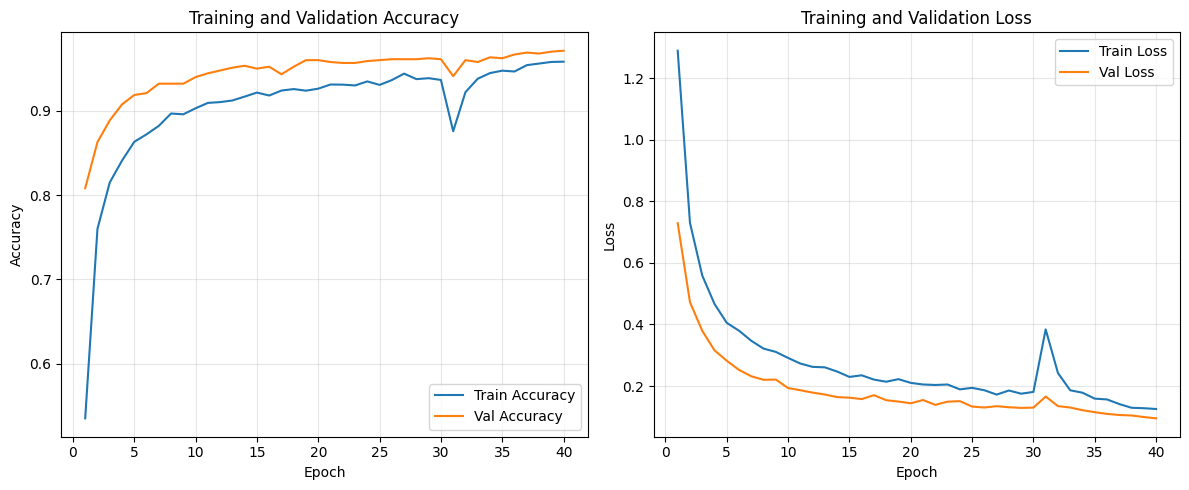

In [ ]:
# Plot training and validation accuracy/loss
import matplotlib.pyplot as plt
import numpy as np

# Collect metrics from warmup and optional fine-tune
acc = list(history.history.get('accuracy', []))
val_acc = list(history.history.get('val_accuracy', []))
loss = list(history.history.get('loss', []))
val_loss = list(history.history.get('val_loss', []))

try:
    acc += list(history_ft.history.get('accuracy', []))
    val_acc += list(history_ft.history.get('val_accuracy', []))
    loss += list(history_ft.history.get('loss', []))
    val_loss += list(history_ft.history.get('val_loss', []))
except NameError:
    pass

epochs = np.arange(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

---
## 📊 Evaluation & Metrics

This section evaluates the trained EfficientNetB0 model on the **test set** and visualises:
- Learning rate schedule across epochs
- Confusion matrix (normalised & raw counts)
- Per-class classification report (precision, recall, F1-score)
- Per-class accuracy bar chart
- Prediction gallery with true vs predicted labels


### 🔧 Dependencies

In [ ]:
# Ensure scikit-learn is available (needed for classification_report & confusion_matrix)
try:
    import sklearn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")


### 📉 Learning Rate Schedule

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Collect LR history from warmup + fine-tune phases
lr_warmup = history.history.get('lr', [])
lr_finetune = []
try:
    lr_finetune = history_ft.history.get('lr', [])
except NameError:
    pass

all_lr = list(lr_warmup) + list(lr_finetune)

if all_lr:
    fig, ax = plt.subplots(figsize=(10, 4))
    epochs_lr = np.arange(1, len(all_lr) + 1)
    ax.semilogy(epochs_lr, all_lr, color='darkorange', linewidth=2.5, marker='o',
                markersize=4, label='Learning Rate')

    # Mark the boundary between warmup and fine-tune
    if lr_warmup and lr_finetune:
        boundary = len(lr_warmup)
        ax.axvline(boundary + 0.5, color='gray', linestyle='--', alpha=0.7,
                   label='Fine-tune start')
        ax.text(boundary + 0.7, max(all_lr) * 0.6, 'Fine-tune
phase',
                fontsize=9, color='gray')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Learning Rate (log scale)', fontsize=12)
    ax.set_title('Learning Rate Schedule (ReduceLROnPlateau)', fontsize=14, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("LR history not captured. Keras only stores 'lr' when ReduceLROnPlateau is active.")
    print("Re-run training with the callbacks to see the LR schedule plot.")


### 🔢 Confusion Matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ── Generate predictions on the test set ──────────────────────────────────
# test_generator has shuffle=False so predictions align with true labels
print("Generating predictions on test set...")
test_generator.reset()
test_steps_cm = len(test_generator)

y_pred_prob = model.predict(test_generator, steps=test_steps_cm, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
# Shorten names for display
short_names = [n.replace('Tomato_', '').replace('Tomato__', '') for n in class_names]

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, title, fmt, cmap in zip(
    axes,
    [cm_norm, cm],
    ['Normalised Confusion Matrix', 'Raw Count Confusion Matrix'],
    ['.2f', 'd'],
    ['Blues', 'YlOrRd']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap=cmap,
        xticklabels=short_names, yticklabels=short_names,
        ax=ax, linewidths=0.5, linecolor='lightgray',
        annot_kws={'size': 10}
    )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('EfficientNetB0 — Confusion Matrix on Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 📋 Per-class Classification Report

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    y_true, y_pred,
    target_names=short_names,
    output_dict=True
)

# Convert to DataFrame for a cleaner display
df_report = pd.DataFrame(report_dict).T
df_report = df_report.round(3)

# Style the table
styled = (
    df_report.style
    .background_gradient(subset=['precision', 'recall', 'f1-score'], cmap='RdYlGn', vmin=0.5, vmax=1.0)
    .format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1-score': '{:.3f}', 'support': '{:.0f}'})
    .set_caption('EfficientNetB0 — Classification Report (Test Set)')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px'), ('padding', '6px')]},
        {'selector': 'td', 'props': [('font-size', '12px'), ('padding', '5px')]},
    ])
)

print(classification_report(y_true, y_pred, target_names=short_names))
display(styled)


### 📊 Per-class Accuracy

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Compute per-class accuracy from the confusion matrix
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Sort by accuracy descending
sorted_idx = np.argsort(per_class_acc)
sorted_names = [short_names[i] for i in sorted_idx]
sorted_acc   = per_class_acc[sorted_idx]

# Color: green if >= 0.85, yellow if >= 0.70, red otherwise
colors = ['#2ecc71' if a >= 0.85 else '#f39c12' if a >= 0.70 else '#e74c3c'
          for a in sorted_acc]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_names, sorted_acc, color=colors, edgecolor='white', height=0.6)

# Annotate bars
for bar, acc_val in zip(bars, sorted_acc):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
        f'{acc_val:.1%}', va='center', fontsize=11, fontweight='bold'
    )

ax.set_xlim(0, 1.12)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('EfficientNetB0 — Per-class Accuracy on Test Set', fontsize=14, fontweight='bold')
ax.axvline(0.85, color='green',  linestyle='--', alpha=0.5, label='85% threshold')
ax.axvline(0.70, color='orange', linestyle='--', alpha=0.5, label='70% threshold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Overall accuracy annotation
overall = np.sum(np.diag(cm)) / np.sum(cm)
ax.set_xlabel(f'Accuracy    |    Overall Test Accuracy: {overall:.2%}', fontsize=12)

plt.tight_layout()
plt.show()


### 🖼️ Prediction Gallery

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pull one raw batch from test directory for display (without EfficientNet preprocessing)
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG

raw_gen = IDG(rescale=1.0/255)
raw_test = raw_gen.flow_from_directory(
    test_generator.directory,
    target_size=(224, 224),
    batch_size=9,
    class_mode='sparse',
    shuffle=True,
    seed=42
)

# Get one batch of raw images and their true labels
raw_images, raw_labels = next(raw_test)

# Get preprocessed batch for prediction
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
preproc_images = eff_preprocess(raw_images * 255.0)
preds_prob = model.predict(preproc_images, verbose=0)
preds = np.argmax(preds_prob, axis=1)
confs = np.max(preds_prob, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle('EfficientNetB0 — Prediction Gallery (Test Set Samples)',
             fontsize=15, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(raw_images[i])

    true_cls = short_names[int(raw_labels[i])]
    pred_cls = short_names[preds[i]]
    conf     = confs[i]
    correct  = int(raw_labels[i]) == preds[i]

    border_color = '#2ecc71' if correct else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    status_icon = '✓' if correct else '✗'
    title_color = '#27ae60' if correct else '#c0392b'

    ax.set_title(
        f'{status_icon}  True: {true_cls}\nPred: {pred_cls}  ({conf:.1%})',
        fontsize=9.5, color=title_color, fontweight='bold', pad=6
    )
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"\nGreen border = correct prediction | Red border = wrong prediction")


In [ ]:
# Save trained model to models directory, robust to working dir
from pathlib import Path
import os

# Detect models directory relative to notebook working directory
candidates = [Path('models'), Path('../models'), Path('../../models')]
models_dir = None
for p in candidates:
    if p.exists():
        models_dir = p
        break
if models_dir is None:
    models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

save_path = models_dir / 'tomato_effnetb0.keras'
model.save(save_path)
print(f"Saved model to: {save_path.resolve()}")

# Optionally also save best checkpoint copy if exists
checkpoint_path = Path('best_effnetb0.keras')
if checkpoint_path.exists():
    dest_ckpt = models_dir / 'best_effnetb0.keras'
    import shutil
    shutil.copy2(checkpoint_path, dest_ckpt)
    print(f"Copied best checkpoint to: {dest_ckpt.resolve()}")

Saved model to: C:\Users\2021ICTS28\Desktop\Tomato_Disease_Prediction_System\models\tomato_effnetb0.keras
Copied best checkpoint to: C:\Users\2021ICTS28\Desktop\Tomato_Disease_Prediction_System\models\best_effnetb0.keras
